<a href="https://colab.research.google.com/github/dariakadina/satprak/blob/main/hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flight Delays Report for the Ministry of Transport

## Goal
In this report, we study the nature and characteristics of flight delays in order to identify operational problem areas and support decision-making.

We focus not on average values alone, but on patterns that may reveal bottlenecks:
- whether delays depend on the day of week;
- whether delays rise during peak hours;
- which airports contribute most to the delay problem;
- which airlines are associated with higher delays;
- how cancellation reasons are distributed;
- how departure delays propagate into arrival delays.

Each section contains:
1. a brief research question;
2. code and outputs;
3. a short conclusion.

In [9]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

## 1. Data loading and primary inspection

We load the datasets, inspect their structure, and prepare them for analysis.

In [8]:
# File paths. Change them if needed.
flights_path = "flights.csv"
airlines_path = "airlines.csv"
airports_path = "airports.csv"

flights = pd.read_csv(flights_path, low_memory=False)
airlines = pd.read_csv(airlines_path)
airports = pd.read_csv(airports_path)

print("flights shape:", flights.shape)
print("airlines shape:", airlines.shape)
print("airports shape:", airports.shape)

display(flights.head())
display(airlines.head())
display(airports.head())

flights shape: (5819079, 31)
airlines shape: (14, 2)
airports shape: (322, 7)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


### Data preparation

We convert time fields into a convenient numeric format, create interpretable labels, and merge airline and airport names.


In [10]:
# Working copy
df = flights.copy()

# Convert columns to numeric where needed
numeric_cols = [
    "DEPARTURE_DELAY", "ARRIVAL_DELAY", "AIR_SYSTEM_DELAY", "SECURITY_DELAY",
    "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY",
    "ELAPSED_TIME", "AIR_TIME", "DISTANCE", "TAXI_OUT", "TAXI_IN",
    "SCHEDULED_TIME", "DIVERTED", "CANCELLED"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert HHMM to minutes from midnight
def hhmm_to_minutes(x):
    if pd.isna(x):
        return np.nan
    try:
        s = str(int(float(x))).zfill(4)
        hh = int(s[:2])
        mm = int(s[2:])
        if hh > 23 or mm > 59:
            return np.nan
        return hh * 60 + mm
    except:
        return np.nan

time_cols = [
    "SCHEDULED_DEPARTURE", "DEPARTURE_TIME", "WHEELS_OFF",
    "SCHEDULED_ARRIVAL", "ARRIVAL_TIME", "WHEELS_ON"
]

for col in time_cols:
    if col in df.columns:
        df[col + "_MIN"] = df[col].apply(hhmm_to_minutes)

weekday_map = {
    1: "Mon",
    2: "Tue",
    3: "Wed",
    4: "Thu",
    5: "Fri",
    6: "Sat",
    7: "Sun"
}
df["WEEKDAY_NAME"] = df["DAY_OF_WEEK"].map(weekday_map)

# Scheduled departure hour
df["SCHEDULED_DEP_HOUR"] = (df["SCHEDULED_DEPARTURE_MIN"] // 60).astype("Int64")

# Serious delay indicators
df["DEP_DELAY_15PLUS"] = (df["DEPARTURE_DELAY"] >= 15).astype("Int64")
df["ARR_DELAY_15PLUS"] = (df["ARRIVAL_DELAY"] >= 15).astype("Int64")

# Cancellation reason mapping
cancel_reason_map = {
    "A": "Airline/Carrier",
    "B": "Weather",
    "C": "National Air System",
    "D": "Security"
}
if "CANCELLATION_REASON" in df.columns:
    df["CANCELLATION_REASON_NAME"] = df["CANCELLATION_REASON"].map(cancel_reason_map)

# Distance groups
df["DISTANCE_GROUP"] = pd.cut(
    df["DISTANCE"],
    bins=[0, 500, 1000, 1500, 2000, 3000, np.inf],
    labels=["0-500", "501-1000", "1001-1500", "1501-2000", "2001-3000", "3000+"]
)

# Merge airline names
df = df.merge(
    airlines.rename(columns={"IATA_CODE": "AIRLINE", "AIRLINE": "AIRLINE_NAME"}),
    on="AIRLINE",
    how="left"
)

# Merge origin airport info
origin_airports = airports.rename(columns={
    "IATA_CODE": "ORIGIN_AIRPORT",
    "AIRPORT": "ORIGIN_AIRPORT_NAME",
    "CITY": "ORIGIN_CITY",
    "STATE": "ORIGIN_STATE"
})[["ORIGIN_AIRPORT", "ORIGIN_AIRPORT_NAME", "ORIGIN_CITY", "ORIGIN_STATE"]]

df = df.merge(origin_airports, on="ORIGIN_AIRPORT", how="left")

# Merge destination airport info
dest_airports = airports.rename(columns={
    "IATA_CODE": "DESTINATION_AIRPORT",
    "AIRPORT": "DESTINATION_AIRPORT_NAME",
    "CITY": "DEST_CITY",
    "STATE": "DEST_STATE"
})[["DESTINATION_AIRPORT", "DESTINATION_AIRPORT_NAME", "DEST_CITY", "DEST_STATE"]]

df = df.merge(dest_airports, on="DESTINATION_AIRPORT", how="left")

display(df.head())

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARR_DELAY_15PLUS,CANCELLATION_REASON_NAME,DISTANCE_GROUP,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,DESTINATION_AIRPORT_NAME,DEST_CITY,DEST_STATE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,0,NaN,1001-1500,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,Seattle-Tacoma International Airport,Seattle,WA
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,0,NaN,2001-3000,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,Palm Beach International Airport,West Palm Beach,FL
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,0,NaN,2001-3000,US Airways Inc.,San Francisco International Airport,San Francisco,CA,Charlotte Douglas International Airport,Charlotte,NC
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,0,NaN,2001-3000,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,Miami International Airport,Miami,FL
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,0,NaN,1001-1500,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,Ted Stevens Anchorage International Airport,Anchorage,AK


In [12]:
summary = pd.DataFrame({
    "metric": [
        "Total flights",
        "Cancelled flights",
        "Diverted flights",
        "Average departure delay, min",
        "Average arrival delay, min",
        "Share of departures delayed 15+ min, %",
        "Share of arrivals delayed 15+ min, %"
    ],
    "value": [
        len(df),
        df["CANCELLED"].sum(skipna=True),
        df["DIVERTED"].sum(skipna=True),
        round(df["DEPARTURE_DELAY"].mean(skipna=True), 2),
        round(df["ARRIVAL_DELAY"].mean(skipna=True), 2),
        round(df["DEP_DELAY_15PLUS"].mean(skipna=True) * 100, 2),
        round(df["ARR_DELAY_15PLUS"].mean(skipna=True) * 100, 2)
    ]
})

display(summary)

,metric,value
0,Total flights,5819079.00
1,Cancelled flights,89884.00
2,Diverted flights,15187.00
3,"Average departure delay, min",9.37
4,"Average arrival delay, min",4.41
5,"Share of departures delayed 15+ min, %",18.17
6,"Share of arrivals delayed 15+ min, %",18.28


## 2. Result 1: Are delays concentrated on specific days of the week?

We test whether the delay problem is uniform across the week or whether some days create a much larger operational load.

In [13]:
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

weekday_stats = (
    df.groupby("WEEKDAY_NAME", dropna=False)
      .agg(
          flights=("FLIGHT_NUMBER", "count"),
          avg_dep_delay=("DEPARTURE_DELAY", "mean"),
          avg_arr_delay=("ARRIVAL_DELAY", "mean"),
          dep_delay_15_share=("DEP_DELAY_15PLUS", "mean"),
          arr_delay_15_share=("ARR_DELAY_15PLUS", "mean")
      )
      .reindex(weekday_order)
      .reset_index()
)

weekday_stats["dep_delay_15_share"] = weekday_stats["dep_delay_15_share"] * 100
weekday_stats["arr_delay_15_share"] = weekday_stats["arr_delay_15_share"] * 100

display(weekday_stats.round(2))

,WEEKDAY_NAME,flights,avg_dep_delay,avg_arr_delay,dep_delay_15_share,arr_delay_15_share
0,Mon,865543,10.87,6.00,19.14,19.21
1,Tue,844600,9.16,4.25,17.74,17.9
2,Wed,855897,8.65,3.85,17.65,17.95
3,Thu,872521,9.96,5.67,19.09,19.68
4,Fri,862209,9.43,4.76,18.75,18.96
5,Sat,700545,7.83,1.85,16.22,15.75
6,Sun,817764,9.40,3.96,18.23,17.97


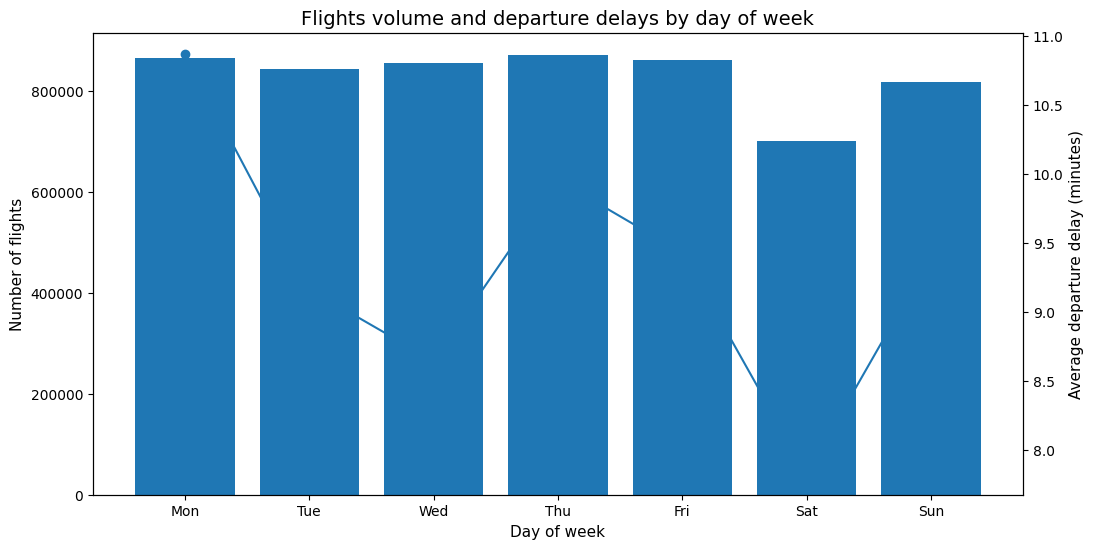

In [14]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(weekday_stats["WEEKDAY_NAME"], weekday_stats["flights"])
ax1.set_title("Flights volume and departure delays by day of week")
ax1.set_xlabel("Day of week")
ax1.set_ylabel("Number of flights")

ax2 = ax1.twinx()
ax2.plot(weekday_stats["WEEKDAY_NAME"], weekday_stats["avg_dep_delay"], marker="o")
ax2.set_ylabel("Average departure delay (minutes)")

plt.show()

### Conclusion

If the chart shows that delay intensity rises on specific weekdays together with flight volume, this suggests uneven system load. In that case, the problem is not just “average delay”, but congestion concentrated on particular days.

## 3. Result 2: Do delays increase during peak hours?

We study whether delays become more severe during certain scheduled departure hours. If yes, this points to airport and runway congestion during peak demand windows.

In [15]:
hour_stats = (
    df.dropna(subset=["SCHEDULED_DEP_HOUR"])
      .groupby("SCHEDULED_DEP_HOUR")
      .agg(
          flights=("FLIGHT_NUMBER", "count"),
          avg_dep_delay=("DEPARTURE_DELAY", "mean"),
          avg_arr_delay=("ARRIVAL_DELAY", "mean"),
          dep_delay_15_share=("DEP_DELAY_15PLUS", "mean")
      )
      .reset_index()
)

hour_stats["dep_delay_15_share"] = hour_stats["dep_delay_15_share"] * 100

display(hour_stats.head(10).round(2))

,SCHEDULED_DEP_HOUR,flights,avg_dep_delay,avg_arr_delay,dep_delay_15_share
0,0,14664,7.20,0.81,16.56
1,1,5159,8.09,3.89,17.41
2,2,1414,7.27,1.82,17.26
3,3,778,8.92,1.73,20.82
4,4,531,10.34,3.70,24.11
5,5,118051,1.90,-3.78,5.76
6,6,406940,2.11,-2.61,6.53
7,7,393947,3.25,-1.50,8.73
8,8,381014,4.69,-0.19,10.85
9,9,351403,5.68,0.97,12.93


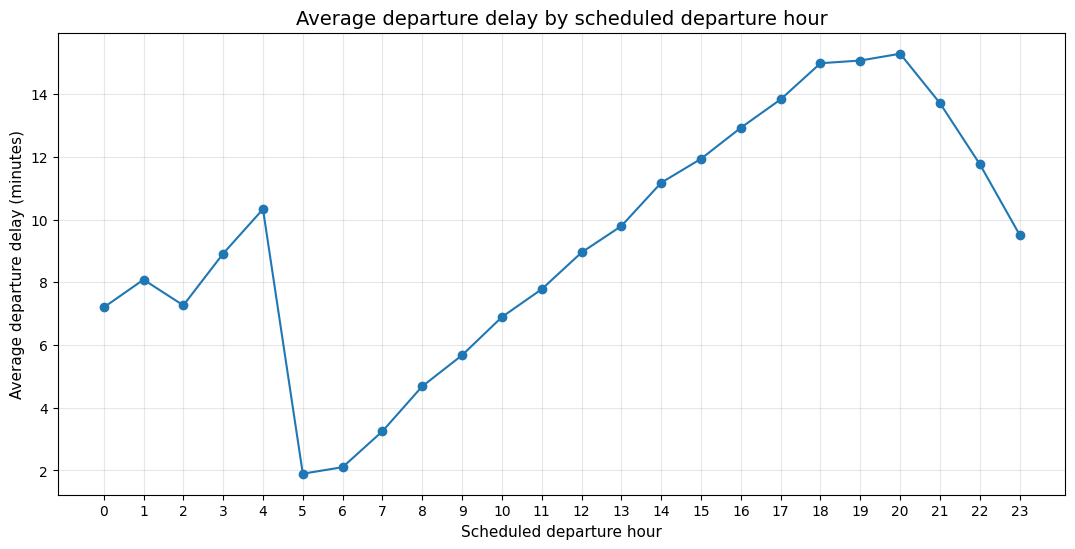

In [16]:
plt.figure(figsize=(13, 6))
plt.plot(hour_stats["SCHEDULED_DEP_HOUR"], hour_stats["avg_dep_delay"], marker="o")
plt.title("Average departure delay by scheduled departure hour")
plt.xlabel("Scheduled departure hour")
plt.ylabel("Average departure delay (minutes)")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

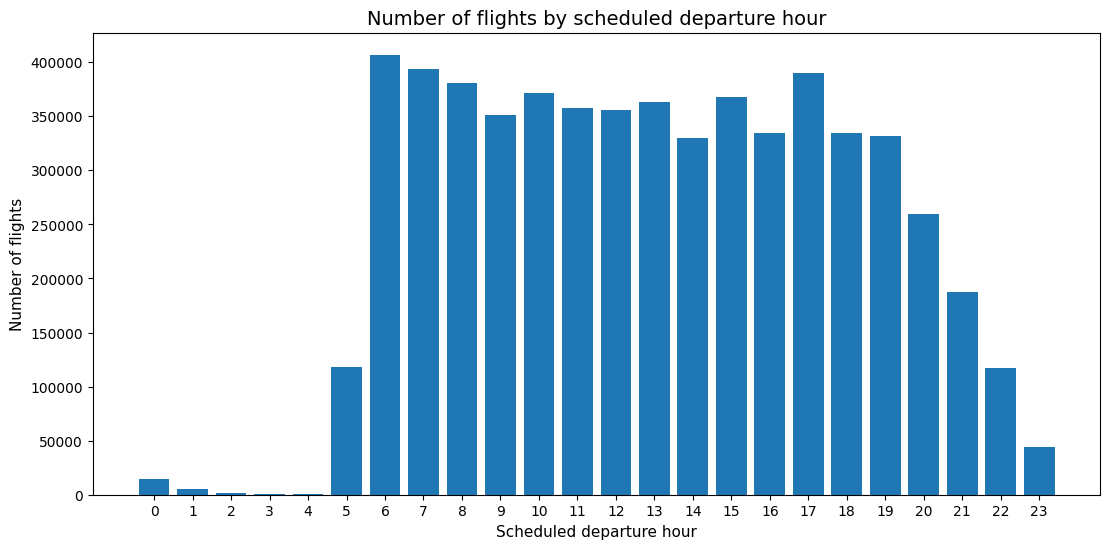

In [17]:
plt.figure(figsize=(13, 6))
plt.bar(hour_stats["SCHEDULED_DEP_HOUR"], hour_stats["flights"])
plt.title("Number of flights by scheduled departure hour")
plt.xlabel("Scheduled departure hour")
plt.ylabel("Number of flights")
plt.xticks(range(0, 24))
plt.show()

### Conclusion

If delay peaks coincide with high traffic hours, this supports the hypothesis that the system struggles during demand spikes. This is a strong operational signal for slot redistribution, staffing, and ground-capacity adjustments.

## 4. Result 3: Which airports create the biggest delay problem?

We identify airports that combine both high traffic and poor delay performance. This is more useful for policy than looking only at national averages.

In [18]:
airport_stats = (
    df.groupby(["ORIGIN_AIRPORT", "ORIGIN_AIRPORT_NAME", "ORIGIN_CITY", "ORIGIN_STATE"], dropna=False)
      .agg(
          flights=("FLIGHT_NUMBER", "count"),
          avg_dep_delay=("DEPARTURE_DELAY", "mean"),
          avg_arr_delay=("ARRIVAL_DELAY", "mean"),
          dep_delay_15_share=("DEP_DELAY_15PLUS", "mean"),
          cancelled_share=("CANCELLED", "mean")
      )
      .reset_index()
)

airport_stats["dep_delay_15_share"] = airport_stats["dep_delay_15_share"] * 100
airport_stats["cancelled_share"] = airport_stats["cancelled_share"] * 100

large_airports = airport_stats[airport_stats["flights"] >= airport_stats["flights"].quantile(0.90)].copy()
large_airports = large_airports.sort_values("avg_dep_delay", ascending=False)

display(large_airports.head(15).round(2))

,ORIGIN_AIRPORT,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,flights,avg_dep_delay,avg_arr_delay,dep_delay_15_share,cancelled_share
534,ORD,Chicago O'Hare International Airport,Chicago,IL,285884,14.15,8.60,23.72,2.99
412,EWR,Newark Liberty International Airport,Newark,NJ,101772,13.64,4.49,23.14,3.06
357,BWI,Baltimore-Washington International Airport,Baltimore,MD,86079,13.34,7.25,24.25,1.78
488,LGA,LaGuardia Airport (Marine Air Terminal),New York,NY,99605,13.23,5.63,21.61,4.55
501,MDW,Chicago Midway International Airport,Chicago,IL,80886,12.86,6.05,24.35,2.42
455,IAD,Washington Dulles International Airport,Chantilly,VA,34305,12.78,5.17,20.6,1.62
509,MIA,Miami International Airport,Miami,FL,69341,12.53,7.04,23.11,1.13
541,PBI,Palm Beach International Airport,West Palm Beach,FL,22573,12.30,7.94,22.0,1.57
449,HOU,William P. Hobby Airport,Houston,TX,52042,12.14,7.60,23.41,1.49
472,JFK,John F. Kennedy International Airport (New Yor...,New York,NY,93811,12.13,3.61,20.5,2.05


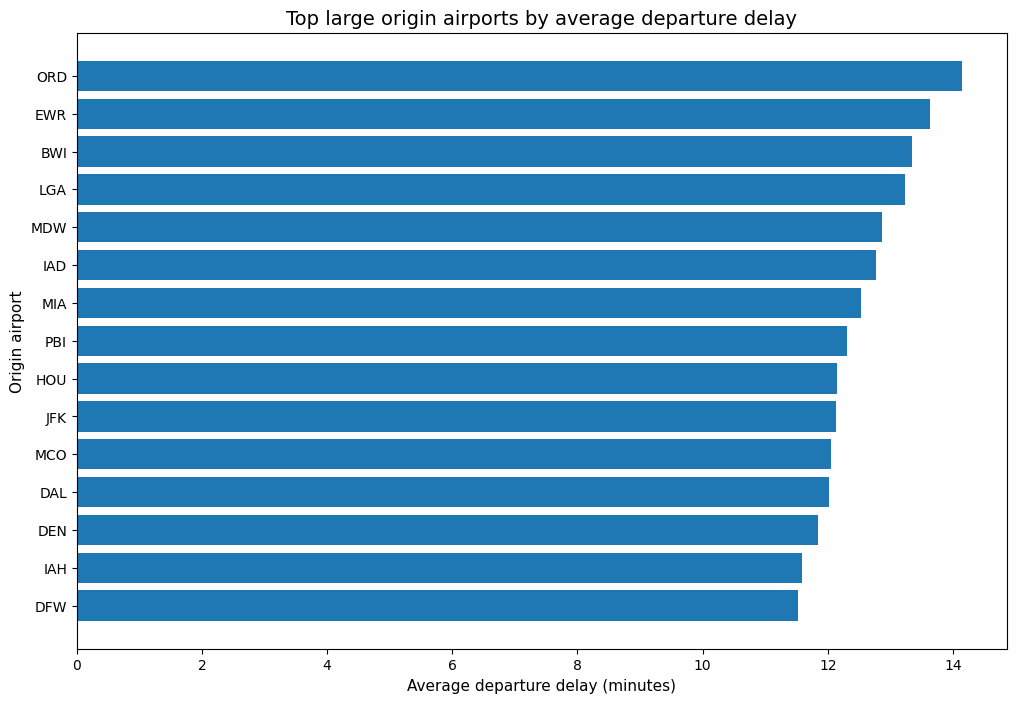

In [19]:
top15_airports = large_airports.head(15).sort_values("avg_dep_delay")

plt.figure(figsize=(12, 8))
plt.barh(top15_airports["ORIGIN_AIRPORT"], top15_airports["avg_dep_delay"])
plt.title("Top large origin airports by average departure delay")
plt.xlabel("Average departure delay (minutes)")
plt.ylabel("Origin airport")
plt.show()

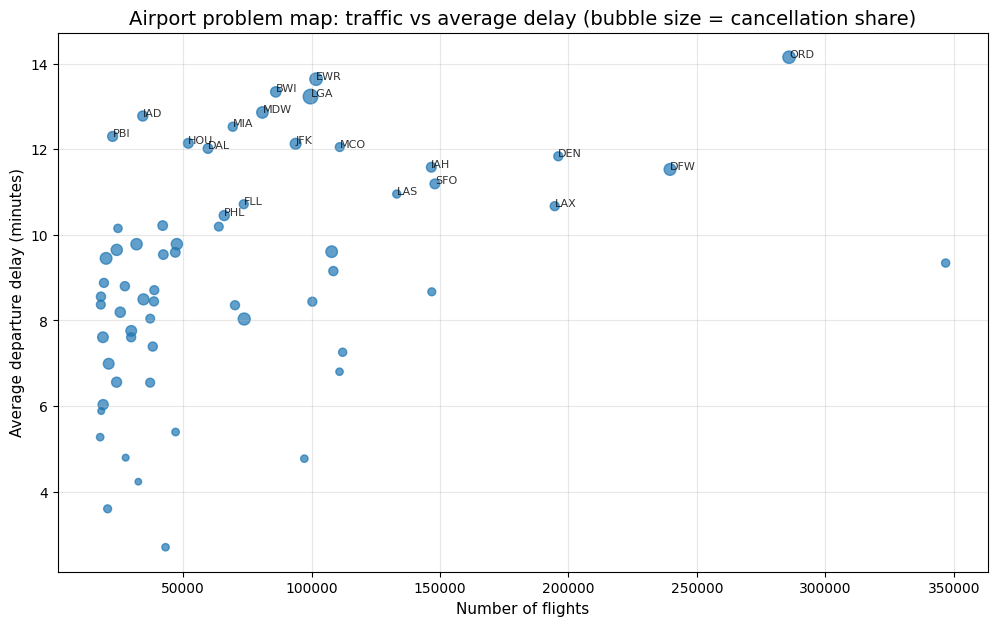

In [20]:
plt.figure(figsize=(12, 7))
plt.scatter(
    large_airports["flights"],
    large_airports["avg_dep_delay"],
    s=large_airports["cancelled_share"] * 20 + 20,
    alpha=0.7
)

for _, row in large_airports.head(20).iterrows():
    plt.annotate(
        row["ORIGIN_AIRPORT"],
        (row["flights"], row["avg_dep_delay"]),
        fontsize=8,
        alpha=0.8
    )

plt.title("Airport problem map: traffic vs average delay (bubble size = cancellation share)")
plt.xlabel("Number of flights")
plt.ylabel("Average departure delay (minutes)")
plt.grid(alpha=0.3)
plt.show()

### Conclusion

Airports in the upper-right area of the chart are the main operational problem points: they handle a large number of flights and also produce substantial delays. If cancellation bubbles are also large, the issue is even more serious.

## 5. Result 4: Which airlines are associated with larger delays?

We compare airlines not only by average delay, but also by the share of seriously delayed flights.

In [21]:
airline_stats = (
    df.groupby(["AIRLINE", "AIRLINE_NAME"], dropna=False)
      .agg(
          flights=("FLIGHT_NUMBER", "count"),
          avg_dep_delay=("DEPARTURE_DELAY", "mean"),
          avg_arr_delay=("ARRIVAL_DELAY", "mean"),
          dep_delay_15_share=("DEP_DELAY_15PLUS", "mean"),
          cancelled_share=("CANCELLED", "mean")
      )
      .reset_index()
)

airline_stats["dep_delay_15_share"] = airline_stats["dep_delay_15_share"] * 100
airline_stats["cancelled_share"] = airline_stats["cancelled_share"] * 100

airline_stats = airline_stats[airline_stats["flights"] >= 1000].copy()
airline_stats = airline_stats.sort_values("avg_dep_delay", ascending=False)

display(airline_stats.round(2))

,AIRLINE,AIRLINE_NAME,flights,avg_dep_delay,avg_arr_delay,dep_delay_15_share,cancelled_share
8,NK,Spirit Air Lines,117379,15.94,14.47,26.92,1.71
10,UA,United Air Lines Inc.,515723,14.44,5.43,23.38,1.27
5,F9,Frontier Airlines Inc.,90836,13.35,12.50,22.88,0.65
2,B6,JetBlue Airways,267048,11.51,6.68,21.6,1.60
13,WN,Southwest Airlines Co.,1261855,10.58,4.37,21.04,1.27
7,MQ,American Eagle Airlines Inc.,294632,10.13,6.46,19.11,5.10
12,VX,Virgin America,61903,9.02,4.74,17.82,0.86
0,AA,American Airlines Inc.,725984,8.90,3.45,17.04,1.50
4,EV,Atlantic Southeast Airlines,571977,8.72,6.59,16.96,2.66
9,OO,Skywest Airlines Inc.,588353,7.80,5.85,16.42,1.69


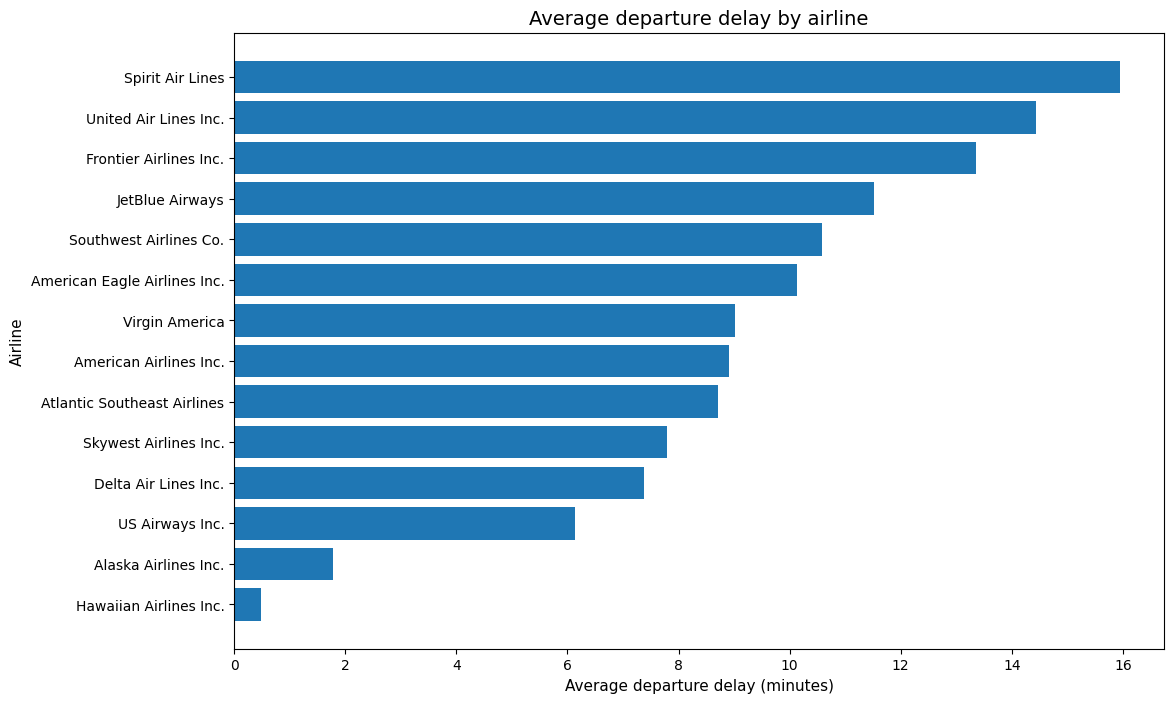

In [22]:
plot_airlines = airline_stats.sort_values("avg_dep_delay")

plt.figure(figsize=(12, 8))
plt.barh(plot_airlines["AIRLINE_NAME"], plot_airlines["avg_dep_delay"])
plt.title("Average departure delay by airline")
plt.xlabel("Average departure delay (minutes)")
plt.ylabel("Airline")
plt.show()

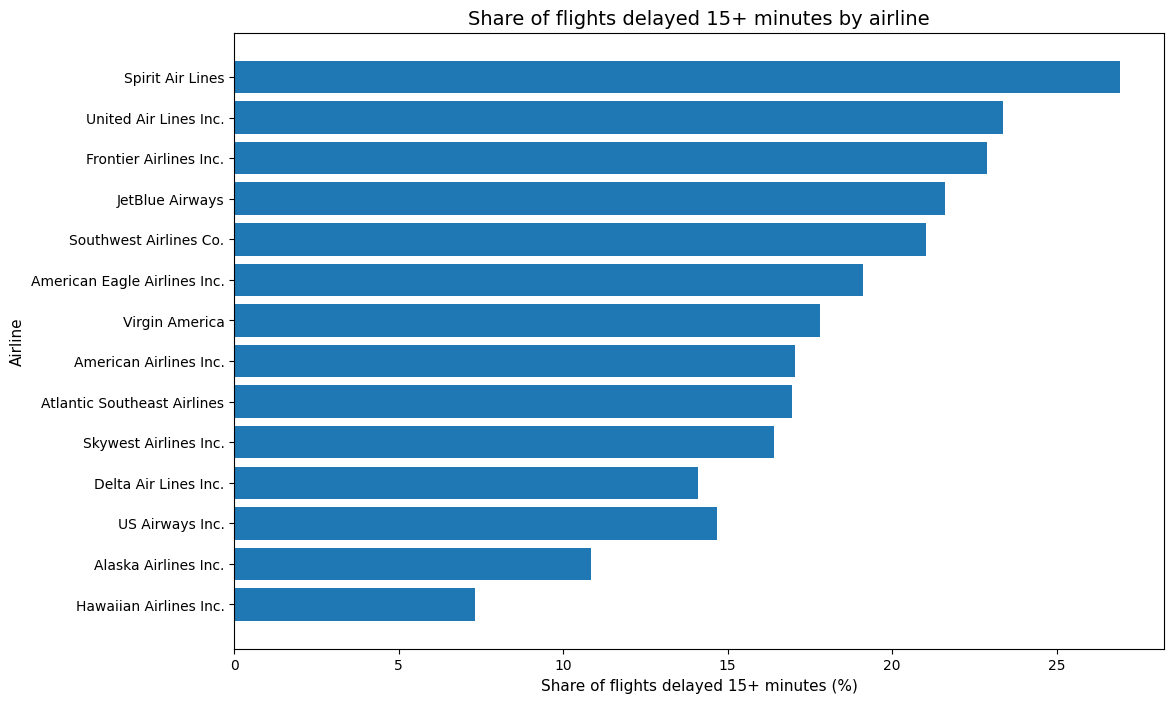

In [23]:
plt.figure(figsize=(12, 8))
plt.barh(plot_airlines["AIRLINE_NAME"], plot_airlines["dep_delay_15_share"])
plt.title("Share of flights delayed 15+ minutes by airline")
plt.xlabel("Share of flights delayed 15+ minutes (%)")
plt.ylabel("Airline")
plt.show()

### Conclusion

If some airlines show consistently higher average delays and higher shares of 15+ minute delays, this may indicate weaker schedule resilience, tighter rotations, or poorer operational recovery from disruptions.

## 6. Result 5: What are the main reasons for cancellations?

Cancelled flights reflect a different class of problems than ordinary delays. We study the structure of cancellation reasons to understand whether disruptions are driven mainly by airlines, weather, the national air system, or security.

In [24]:
cancelled = df[df["CANCELLED"] == 1].copy()

cancel_stats = (
    cancelled["CANCELLATION_REASON_NAME"]
    .value_counts(dropna=False)
    .rename_axis("Reason")
    .reset_index(name="Flights")
)

cancel_stats["Share_%"] = cancel_stats["Flights"] / cancel_stats["Flights"].sum() * 100

display(cancel_stats.round(2))

,Reason,Flights,Share_%
0,Weather,48851,54.35
1,Airline/Carrier,25262,28.11
2,National Air System,15749,17.52
3,Security,22,0.02


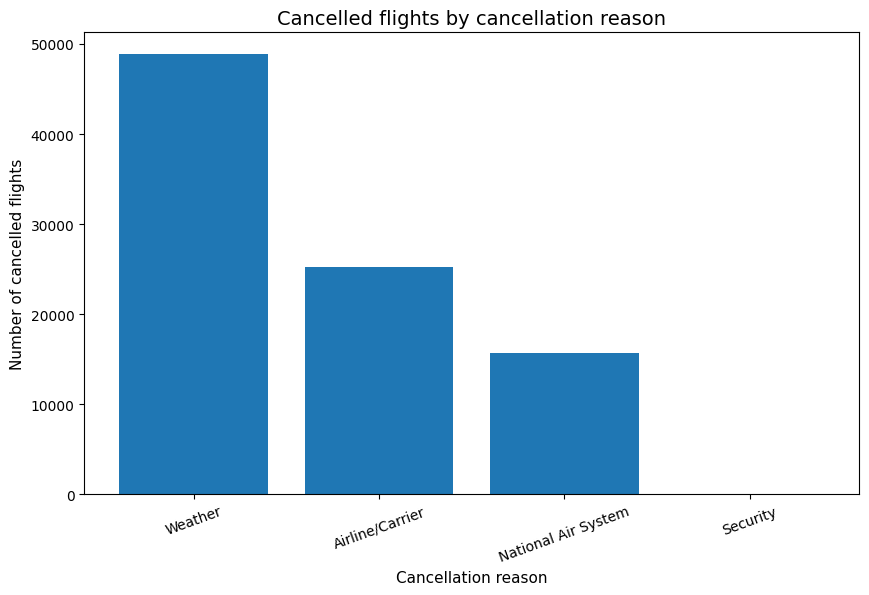

In [25]:
plt.figure(figsize=(10, 6))
plt.bar(cancel_stats["Reason"].fillna("Unknown"), cancel_stats["Flights"])
plt.title("Cancelled flights by cancellation reason")
plt.xlabel("Cancellation reason")
plt.ylabel("Number of cancelled flights")
plt.xticks(rotation=20)
plt.show()

### Conclusion

The dominant cancellation category points to the main source of systemic risk. For example, a large share of National Air System cancellations would indicate infrastructure and airspace management issues, while Airline/Carrier cancellations would suggest internal operational weaknesses.

## 7. Result 6: Do departure delays propagate into arrival delays?

We examine whether a flight that departs late also tends to arrive late. If the relationship is very strong, then early-stage disruptions are not absorbed by the system and continue throughout the network.

In [26]:
delay_corr_df = df[["DEPARTURE_DELAY", "ARRIVAL_DELAY"]].dropna().copy()

corr_value = delay_corr_df["DEPARTURE_DELAY"].corr(delay_corr_df["ARRIVAL_DELAY"])
print(f"Correlation between departure delay and arrival delay: {corr_value:.3f}")

Correlation between departure delay and arrival delay: 0.945


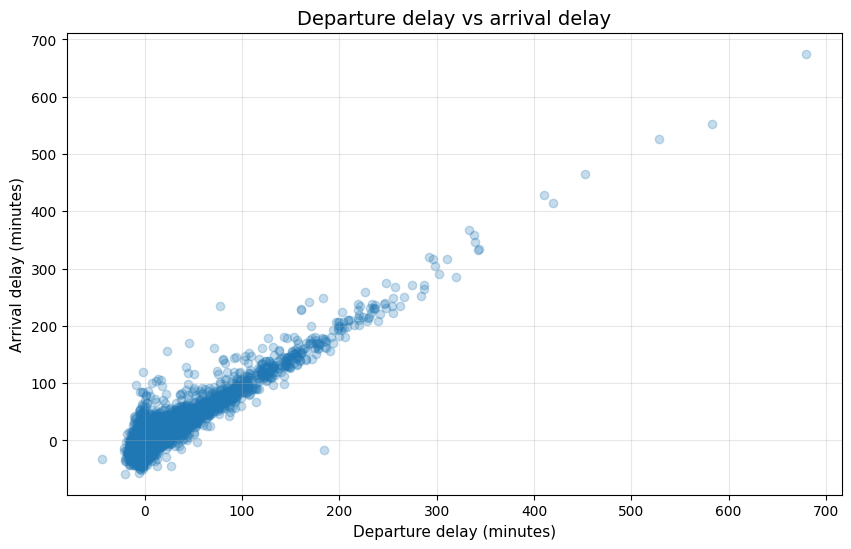

In [27]:
sample_df = delay_corr_df.sample(min(10000, len(delay_corr_df)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample_df["DEPARTURE_DELAY"], sample_df["ARRIVAL_DELAY"], alpha=0.25)
plt.title("Departure delay vs arrival delay")
plt.xlabel("Departure delay (minutes)")
plt.ylabel("Arrival delay (minutes)")
plt.grid(alpha=0.3)
plt.show()

In [28]:
dep_bins = [-np.inf, -15, 0, 15, 30, 60, 120, np.inf]
dep_labels = ["<-15", "-15..0", "0..15", "15..30", "30..60", "60..120", "120+"]

df["DEP_DELAY_BUCKET"] = pd.cut(df["DEPARTURE_DELAY"], bins=dep_bins, labels=dep_labels)

propagation_stats = (
    df.groupby("DEP_DELAY_BUCKET", dropna=False)
      .agg(
          flights=("FLIGHT_NUMBER", "count"),
          avg_arrival_delay=("ARRIVAL_DELAY", "mean")
      )
      .reset_index()
)

display(propagation_stats.round(2))

,DEP_DELAY_BUCKET,flights,avg_arrival_delay
0,<-15,30738,-18.82
1,-15..0,3576570,-9.18
2,0..15,1107060,1.04
3,15..30,380188,16.96
4,30..60,314199,38.39
5,60..120,208143,80.55
6,120+,116028,195.30
7,NaN,86153,NaN


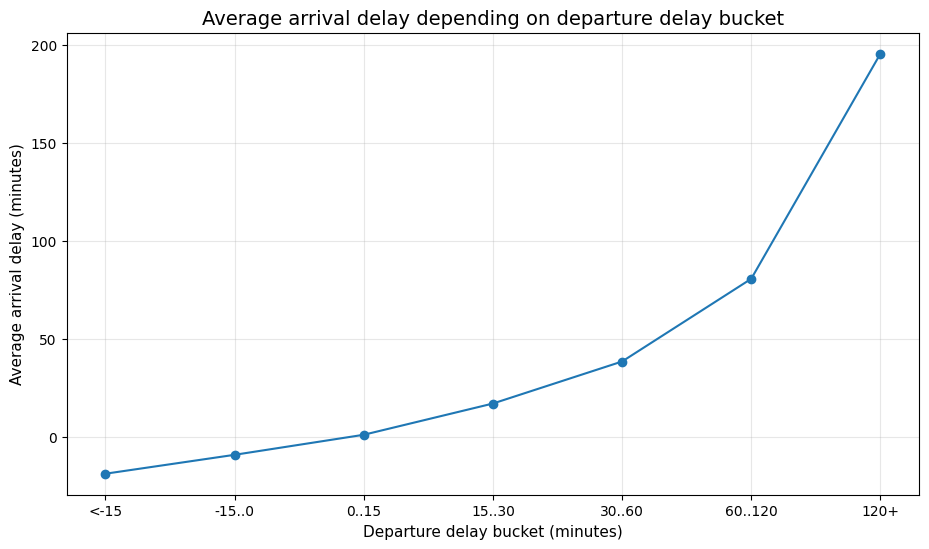

In [29]:
plt.figure(figsize=(11, 6))
plt.plot(
    propagation_stats["DEP_DELAY_BUCKET"].astype(str),
    propagation_stats["avg_arrival_delay"],
    marker="o"
)
plt.title("Average arrival delay depending on departure delay bucket")
plt.xlabel("Departure delay bucket (minutes)")
plt.ylabel("Average arrival delay (minutes)")
plt.grid(alpha=0.3)
plt.show()

### Conclusion

If arrival delay rises almost monotonically with departure delay, then the network does not fully recover from late departures. This means disruption management should focus on preventing the first delay shock rather than only reacting at later stages.

## 8. Additional analysis: Which delay type dominates among late arrivals?

For flights with arrival delays, we compare decomposition components: air system, security, airline, late aircraft, and weather. This helps identify the operational origin of delays.

In [30]:
delay_components = [
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY"
]

available_delay_components = [c for c in delay_components if c in df.columns]

late_arrivals = df[df["ARRIVAL_DELAY"] > 0].copy()

component_sums = late_arrivals[available_delay_components].sum().sort_values(ascending=False)
component_table = component_sums.reset_index()
component_table.columns = ["Delay_Type", "Total_Minutes"]

display(component_table)

,Delay_Type,Total_Minutes
0,LATE_AIRCRAFT_DELAY,24961931.0
1,AIRLINE_DELAY,20172956.0
2,AIR_SYSTEM_DELAY,14335762.0
3,WEATHER_DELAY,3100233.0
4,SECURITY_DELAY,80985.0


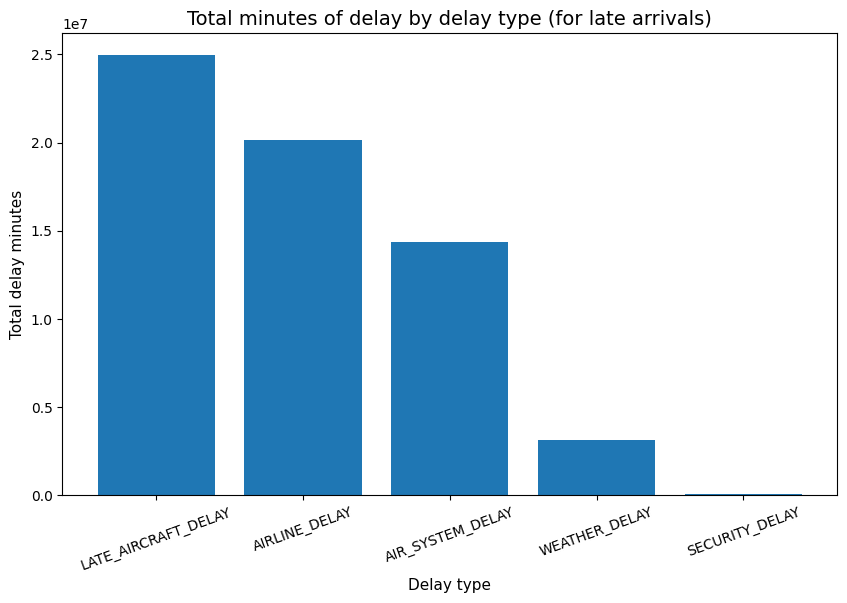

In [31]:
plt.figure(figsize=(10, 6))
plt.bar(component_table["Delay_Type"], component_table["Total_Minutes"])
plt.title("Total minutes of delay by delay type (for late arrivals)")
plt.xlabel("Delay type")
plt.ylabel("Total delay minutes")
plt.xticks(rotation=20)
plt.show()

### Conclusion

The largest delay component indicates the most important source of disruption. For example, if Late Aircraft Delay dominates, this suggests that delays are strongly propagated through aircraft rotations rather than created independently at each airport.

## 9. Final summary table

In [32]:
final_results = pd.DataFrame({
    "Result": [
        "Worst weekday by avg departure delay",
        "Worst scheduled departure hour by avg departure delay",
        "Worst large airport by avg departure delay",
        "Worst airline by avg departure delay",
        "Top cancellation reason",
        "Correlation: departure vs arrival delay"
    ],
    "Value": [
        weekday_stats.loc[weekday_stats["avg_dep_delay"].idxmax(), "WEEKDAY_NAME"],
        int(hour_stats.loc[hour_stats["avg_dep_delay"].idxmax(), "SCHEDULED_DEP_HOUR"]),
        large_airports.loc[large_airports["avg_dep_delay"].idxmax(), "ORIGIN_AIRPORT"],
        airline_stats.loc[airline_stats["avg_dep_delay"].idxmax(), "AIRLINE_NAME"],
        cancel_stats.loc[cancel_stats["Flights"].idxmax(), "Reason"] if len(cancel_stats) > 0 else np.nan,
        round(corr_value, 3)
    ]
})

display(final_results)

,Result,Value
0,Worst weekday by avg departure delay,Mon
1,Worst scheduled departure hour by avg departur...,20
2,Worst large airport by avg departure delay,ORD
3,Worst airline by avg departure delay,Spirit Air Lines
4,Top cancellation reason,Weather
5,Correlation: departure vs arrival delay,0.945


## 10. Final conclusions

This report identifies several problem areas in the flight network:

1. Delays are not evenly distributed across the week.
2. Delays increase during peak scheduled departure hours.
3. Some airports combine both high traffic and poor punctuality, making them key bottlenecks.
4. Airline performance differs materially in delay severity.
5. Cancellation reasons reveal the dominant source of disruptions.
6. Departure delays strongly propagate into arrival delays, meaning early disruption management is critical.

These patterns are more informative for decision-making than national averages alone, because they identify where and when the transport system fails to cope with operational load.